BRAIN TUMOR NOTEBOOK (BINARY CLASSIFICATION)
By DATA DWELLERS


**1. Importing Necessary Libraries**
**This section loads essential Python libraries used for data processing, visualization, and deep learning.**

**Key Libraries & Their Roles:**

 numpy: Handles numerical computations and arrays.*

cv2: Used for reading and processing images (OpenCV).

matplotlib.pyplot: Used for plotting graphs and visualizing images.

sklearn: Includes tools for data preprocessing & evaluation metrics.

keras & tensorflow: Used for building, training, and evaluating deep learning models.

ImageDataGenerator: Generates augmented images to prevent overfitting.**


In [2]:
import numpy as np
from tqdm import tqdm
import cv2
import os
import shutil
import itertools
import imutils
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import VGG16, preprocess_input
from keras import layers
from keras.models import Model, Sequential
from keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping

init_notebook_mode(connected=True)
RANDOM_SEED = 123

**2. Dataset Preparation**


**2.1-Folders for different dataset splits:**

TRAIN/, TEST/, and VAL/ directories are structured with subfolders:

YES/ (Tumor Present)

NO/ (No Tumor)



In [3]:
from IPython.display import clear_output
!pip install imutils
clear_output()

In [4]:
!apt-get install tree
clear_output()
# create new folders
!mkdir TRAIN TEST VAL TRAIN/YES TRAIN/NO TEST/YES TEST/NO VAL/YES VAL/NO
!tree -d

.
├── sample_data
├── TEST
│   ├── NO
│   └── YES
├── TRAIN
│   ├── NO
│   └── YES
└── VAL
    ├── NO
    └── YES

10 directories


**2.2-Downloading Dataset from Kaggle:**

Uses kaggle datasets download to fetch MRI brain scan images.

Splits Data into Train, Validation, and Test Sets:

80% images → TRAIN/

Rest → VAL/

5 images → TEST/ (for final evaluation)

In [5]:
# Install the Kaggle API client if you haven't already.
!pip install kaggle

# Import the necessary library
import os

# Set your Kaggle API credentials. You'll need to create a Kaggle API token
# and download the 'kaggle.json' file. Place it in the location specified below.
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle/'

# Download the dataset.
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection -p /kaggle/working/

# Unzip the dataset if necessary.
!unzip /kaggle/working/brain-mri-images-for-brain-tumor-detection.zip -d /kaggle/working/

# Update the IMG_PATH variable to the correct location.
IMG_PATH = '/kaggle/working/brain_tumor_dataset/'

# split the data by train/val/test
for CLASS in os.listdir(IMG_PATH):
    if not CLASS.startswith('.'):
        IMG_NUM = len(os.listdir(IMG_PATH + CLASS))
        for (n, FILE_NAME) in enumerate(os.listdir(IMG_PATH + CLASS)):
            img = IMG_PATH + CLASS + '/' + FILE_NAME
            if n < 5:
                shutil.copy(img, 'TEST/' + CLASS.upper() + '/' + FILE_NAME)
            elif n < 0.8*IMG_NUM:
                shutil.copy(img, 'TRAIN/'+ CLASS.upper() + '/' + FILE_NAME)
            else:
                shutil.copy(img, 'VAL/'+ CLASS.upper() + '/' + FILE_NAME)

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
 66% 10.0M/15.1M [00:00<00:00, 51.9MB/s]
100% 15.1M/15.1M [00:00<00:00, 63.1MB/s]
Archive:  /kaggle/working/brain-mri-images-for-brain-tumor-detection.zip
  inflating: /kaggle/working/brain_tumor_dataset/no/1 no.jpeg  
  inflating: /kaggle/working/brain_tumor_dataset/no/10 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/11 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/12 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/13 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/14 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/15 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/17 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/18 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/19 no.jpg  
  inflating: /kaggle/working/brain_tumor_dataset/no/2 no.jpeg  
  inflating: /


**3-Loading & Preprocessing Images**


Reads images using cv2.imread().

Resizes images to (224, 224) for input consistency.

Encodes Labels: YES = 1, NO = 0.

Displays sample images to visualize dataset balance.

Checks aspect ratio distribution for preprocessing.



In [6]:
def load_data(dir_path, img_size=(100,100)):
    """
    Load resized images as np.arrays to workspace
    """
    X = []
    y = []
    i = 0
    labels = dict()
    for path in tqdm(sorted(os.listdir(dir_path))):
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path + path):
                if not file.startswith('.'):
                    img = cv2.imread(dir_path + path + '/' + file)
                    # Resize the image to the desired size
                    img = cv2.resize(img, img_size) # Resize image using cv2.resize
                    X.append(img)
                    y.append(i)
            i += 1
    X = np.array(X)
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X, y, labels

In [7]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [8]:
TRAIN_DIR = 'TRAIN/'
TEST_DIR = 'TEST/'
VAL_DIR = 'VAL/'
IMG_SIZE = (224,224)

# use predefined function to load the image data into workspace
X_train, y_train, labels = load_data(TRAIN_DIR, IMG_SIZE)
X_test, y_test, _ = load_data(TEST_DIR, IMG_SIZE)
X_val, y_val, _ = load_data(VAL_DIR, IMG_SIZE)

100%|██████████| 2/2 [00:00<00:00,  3.19it/s]


193 images loaded from TRAIN/ directory.


100%|██████████| 2/2 [00:00<00:00, 50.42it/s]


10 images loaded from TEST/ directory.


100%|██████████| 2/2 [00:00<00:00, 10.89it/s]

50 images loaded from VAL/ directory.


In [9]:
y = dict()
y[0] = []
y[1] = []
for set_name in (y_train, y_val, y_test):
    y[0].append(np.sum(set_name == 0))
    y[1].append(np.sum(set_name == 1))

trace0 = go.Bar(
    x=['Train Set', 'Validation Set', 'Test Set'],
    y=y[0],
    name='No',
    marker=dict(color='#33cc33'),
    opacity=0.7
)
trace1 = go.Bar(
    x=['Train Set', 'Validation Set', 'Test Set'],
    y=y[1],
    name='Yes',
    marker=dict(color='#ff3300'),
    opacity=0.7
)
data = [trace0, trace1]
layout = go.Layout(
    title='Count of classes in each set',
    xaxis={'title': 'Set'},
    yaxis={'title': 'Count'}
)
fig = go.Figure(data, layout)
iplot(fig)

we plotted the samples for the tumor and tumorless images

In [10]:
def plot_samples(X, y, labels_dict, n=50):
    """
    Creates a gridplot for desired number of images (n) from the specified set
    """
    for index in range(len(labels_dict)):
        imgs = X[np.argwhere(y == index)][:n]
        j = 10
        i = int(n/j)

        plt.figure(figsize=(15,6))
        c = 1
        for img in imgs:
            plt.subplot(i,j,c)
            plt.imshow(img[0])

            plt.xticks([])
            plt.yticks([])
            c += 1
        plt.suptitle('Tumor: {}'.format(labels_dict[index]))
        plt.show()

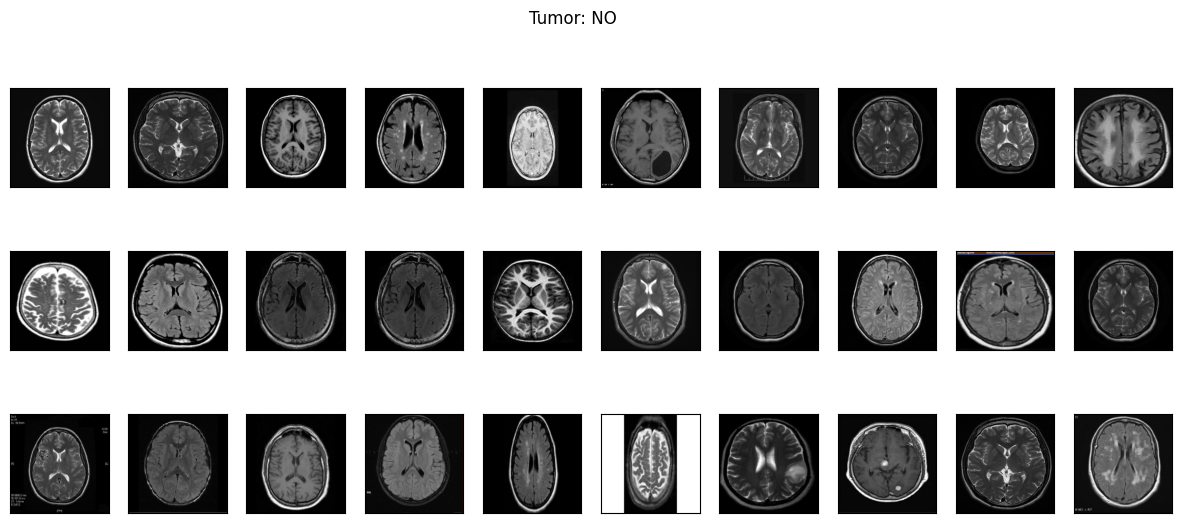

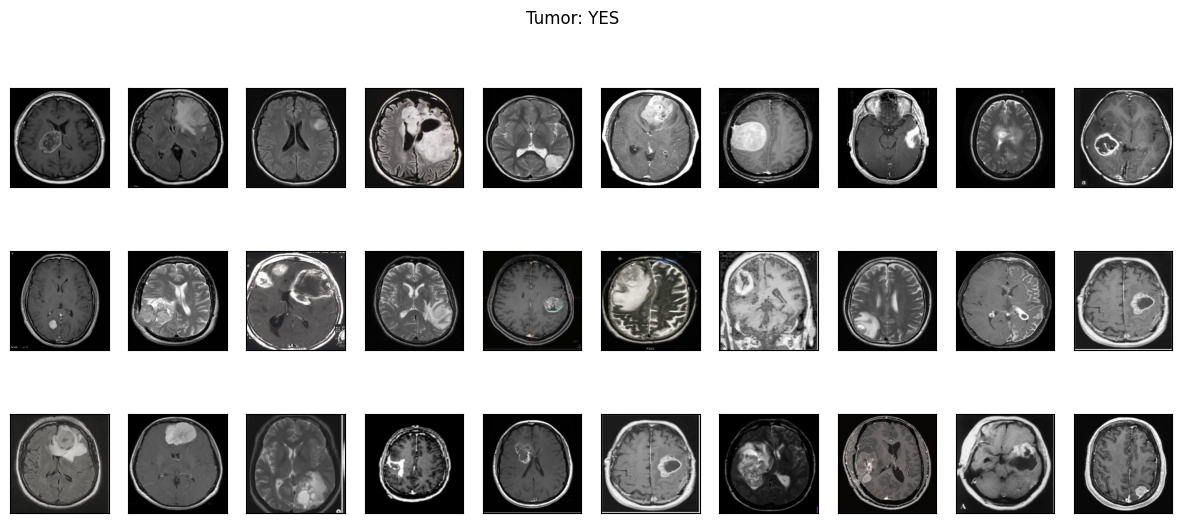

In [11]:
plot_samples(X_train, y_train, labels, 30)

As you can see, images have different width and height and diffent size of "black corners". Since the image size for VGG-16 imput layer is (224,224) some wide images may look weird after resizing. Histogram of ratio distributions (ratio = width/height):**Images have different width and height and diffent size of "black corners".**

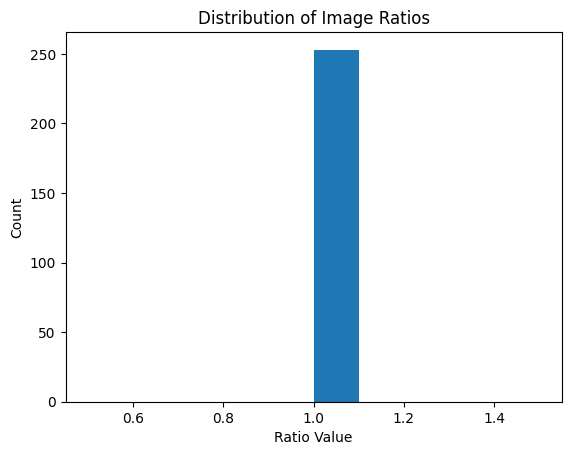

In [12]:
RATIO_LIST = []
for set in (X_train, X_test, X_val):
    for img in set:
        RATIO_LIST.append(img.shape[1]/img.shape[0])

plt.hist(RATIO_LIST)
plt.title('Distribution of Image Ratios')
plt.xlabel('Ratio Value')
plt.ylabel('Count')
plt.show()

**The first step of "normalization" would be to crop the brain out of the images**
**4. Image Preprocessing (Cropping & Augmentation)**


Since brain scans may contain black background areas, cropping is applied to focus on the brain region.

**4.1-CROPPING**
Steps:

Converts images to grayscale (removes color information).

Applies Gaussian Blur & Thresholding to detect important regions.

Finds the largest contour (brain area).

Crops the image to remove unnecessary black areas.

Saves processed images in TRAIN_CROP/, VAL_CROP/, and TEST_CROP/.

In [13]:
import numpy as np
import cv2

def crop_imgs(set_name, add_pixels_value=10, target_size=(100, 100)):
    set_new = []

    for img in set_name:
        if img is None:
            continue  # Ignorer les images non valides

        # Convertir en niveaux de gris et appliquer un seuillage
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
        thresh = cv2.erode(thresh, None, iterations=2)
        thresh = cv2.dilate(thresh, None, iterations=2)

        # Trouver les contours
        cnts, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(cnts) == 0:
            continue  # Ignorer les images sans contours

        # Prendre le plus grand contour
        c = max(cnts, key=cv2.contourArea)

        # Trouver les points extrêmes
        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])

        # Définir les coordonnées de recadrage avec une marge
        x1, y1 = max(extLeft[0] - add_pixels_value, 0), max(extTop[1] - add_pixels_value, 0)
        x2, y2 = min(extRight[0] + add_pixels_value, img.shape[1]), min(extBot[1] + add_pixels_value, img.shape[0])

        # Vérifier que le recadrage est valide
        if x1 >= x2 or y1 >= y2:
            continue  # Ignorer les images mal détectées

        # Recadrer l'image
        new_img = img[y1:y2, x1:x2].copy()

        # Redimensionner à une taille fixe pour homogénéiser le dataset
        new_img = cv2.resize(new_img, target_size, interpolation=cv2.INTER_CUBIC)

        set_new.append(new_img)

    return np.array(set_new)  # Maintenant, toutes les images ont la même taille

# Appliquer la correction
X_train_crop = crop_imgs(X_train)
X_val_crop = crop_imgs(X_val)
X_test_crop = crop_imgs(X_test)


here's an example of cropping an image

In [14]:
import cv2
import os

# ... (rest of your code) ...

img_path = '/content/TRAIN/YES/Y107.jpg'

# Check if the file exists
if not os.path.exists(img_path):
    print(f"Error: Image file not found at {img_path}")
else:
    img = cv2.imread(img_path)

    # Check if the image was loaded successfully
    if img is not None:
        img = cv2.resize(
            img,
            dsize=IMG_SIZE,
            interpolation=cv2.INTER_CUBIC
        )

        # ... (rest of your image processing code) ...

    else:
        print(f"Error: Could not load image from {img_path}")
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)

# threshold the image, then perform a series of erosions +
# dilations to remove any small regions of noise
thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
thresh = cv2.erode(thresh, None, iterations=2)
thresh = cv2.dilate(thresh, None, iterations=2)

# find contours in thresholded image, then grab the largest one
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
c = max(cnts, key=cv2.contourArea)

# find the extreme points
extLeft = tuple(c[c[:, :, 0].argmin()][0])
extRight = tuple(c[c[:, :, 0].argmax()][0])
extTop = tuple(c[c[:, :, 1].argmin()][0])
extBot = tuple(c[c[:, :, 1].argmax()][0])

# add contour on the image
img_cnt = cv2.drawContours(img.copy(), [c], -1, (0, 255, 255), 4)

# add extreme points
img_pnt = cv2.circle(img_cnt.copy(), extLeft, 8, (0, 0, 255), -1)
img_pnt = cv2.circle(img_pnt, extRight, 8, (0, 255, 0), -1)
img_pnt = cv2.circle(img_pnt, extTop, 8, (255, 0, 0), -1)
img_pnt = cv2.circle(img_pnt, extBot, 8, (255, 255, 0), -1)

# crop
ADD_PIXELS = 0
new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()

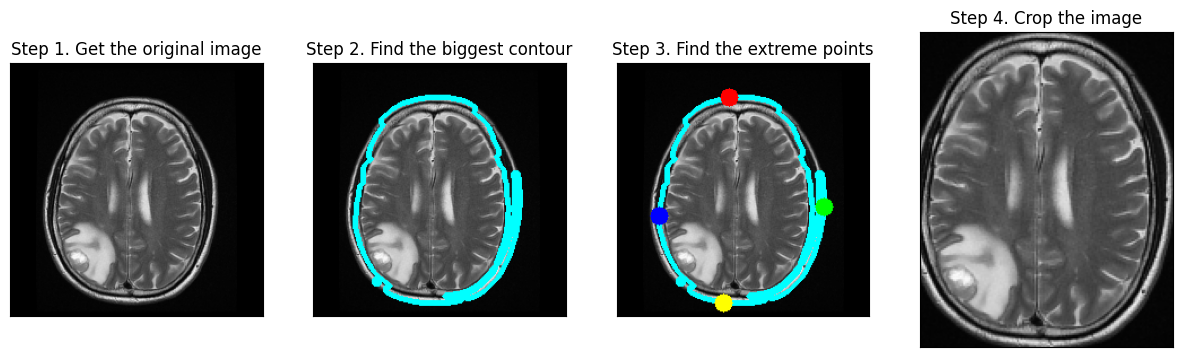

In [15]:
plt.figure(figsize=(15,6))
plt.subplot(141)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('Step 1. Get the original image')
plt.subplot(142)
plt.imshow(img_cnt)
plt.xticks([])
plt.yticks([])
plt.title('Step 2. Find the biggest contour')
plt.subplot(143)
plt.imshow(img_pnt)
plt.xticks([])
plt.yticks([])
plt.title('Step 3. Find the extreme points')
plt.subplot(144)
plt.imshow(new_img)
plt.xticks([])
plt.yticks([])
plt.title('Step 4. Crop the image')
plt.show()

Applying the cropping to the entirety of the dataset

In [16]:
# apply this for each set
X_train_crop = crop_imgs(set_name=X_train)
X_val_crop = crop_imgs(set_name=X_val)
X_test_crop = crop_imgs(set_name=X_test)

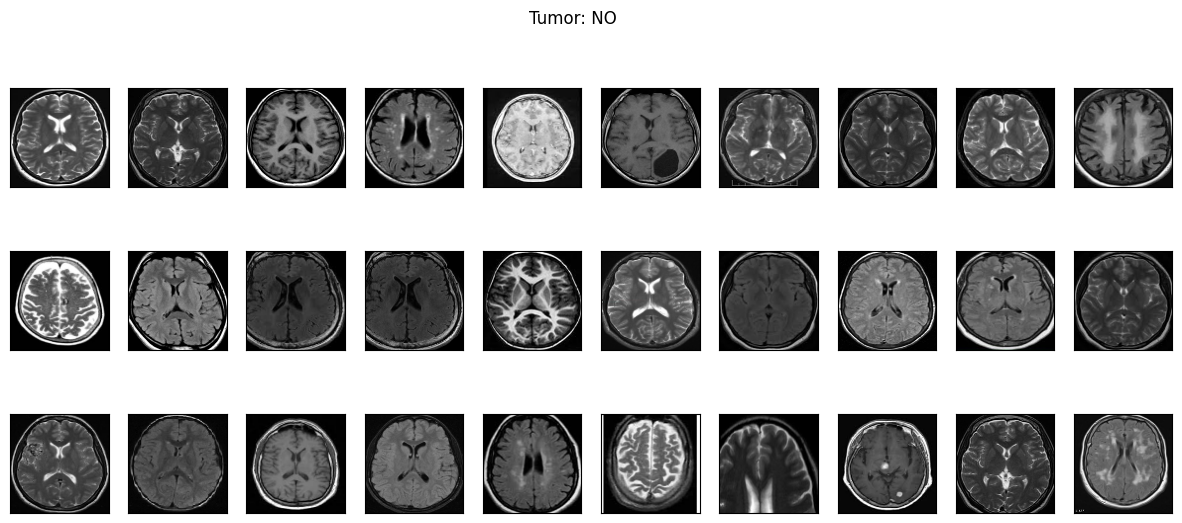

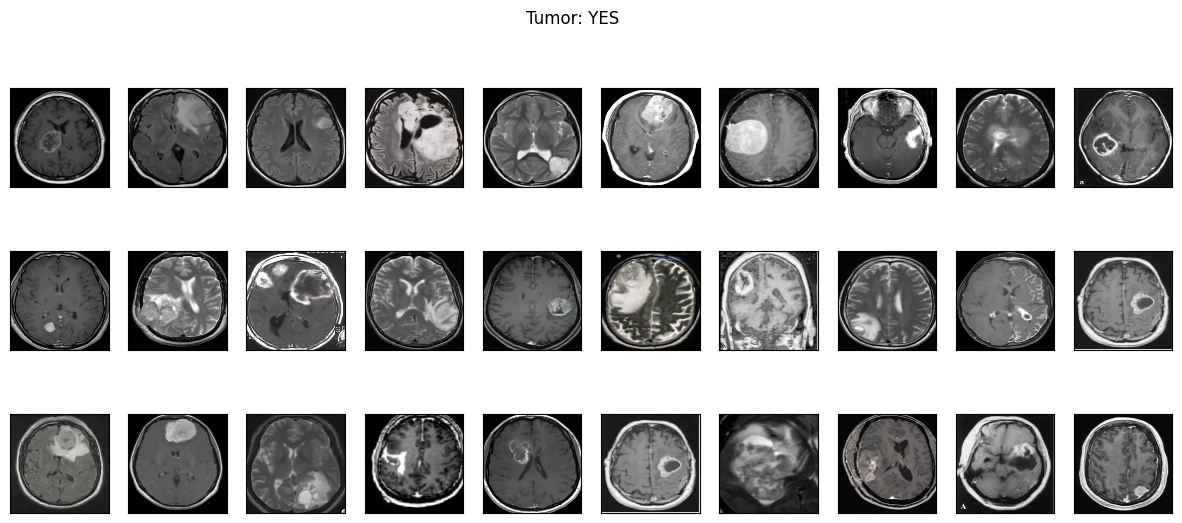

In [17]:
plot_samples(X_train_crop, y_train, labels, 30)

In [18]:
def save_new_images(x_set, y_set, folder_name):
    i = 0
    for (img, imclass) in zip(x_set, y_set):
        if imclass == 0:
            cv2.imwrite(folder_name+'NO/'+str(i)+'.jpg', img)
        else:
            cv2.imwrite(folder_name+'YES/'+str(i)+'.jpg', img)
        i += 1

**saving the new images to the designated csv files**

In [19]:
# saving new images to the folder
!mkdir TRAIN_CROP TEST_CROP VAL_CROP TRAIN_CROP/YES TRAIN_CROP/NO TEST_CROP/YES TEST_CROP/NO VAL_CROP/YES VAL_CROP/NO

save_new_images(X_train_crop, y_train, folder_name='TRAIN_CROP/')
save_new_images(X_val_crop, y_val, folder_name='VAL_CROP/')
save_new_images(X_test_crop, y_test, folder_name='TEST_CROP/')


**The next step would be resizing images to (224,224) and applying preprocessing needed for VGG-16 model input. **




In [20]:
def preprocess_imgs(set_name, img_size):
    """
    Resize and apply VGG-15 preprocessing
    """
    set_new = []
    for img in set_name:
        img = cv2.resize(
            img,
            dsize=img_size,
            interpolation=cv2.INTER_CUBIC
        )
        set_new.append(preprocess_input(img))
    return np.array(set_new)

In [21]:
X_train_prep = preprocess_imgs(set_name=X_train_crop, img_size=IMG_SIZE)
X_test_prep = preprocess_imgs(set_name=X_test_crop, img_size=IMG_SIZE)
X_val_prep = preprocess_imgs(set_name=X_val_crop, img_size=IMG_SIZE)

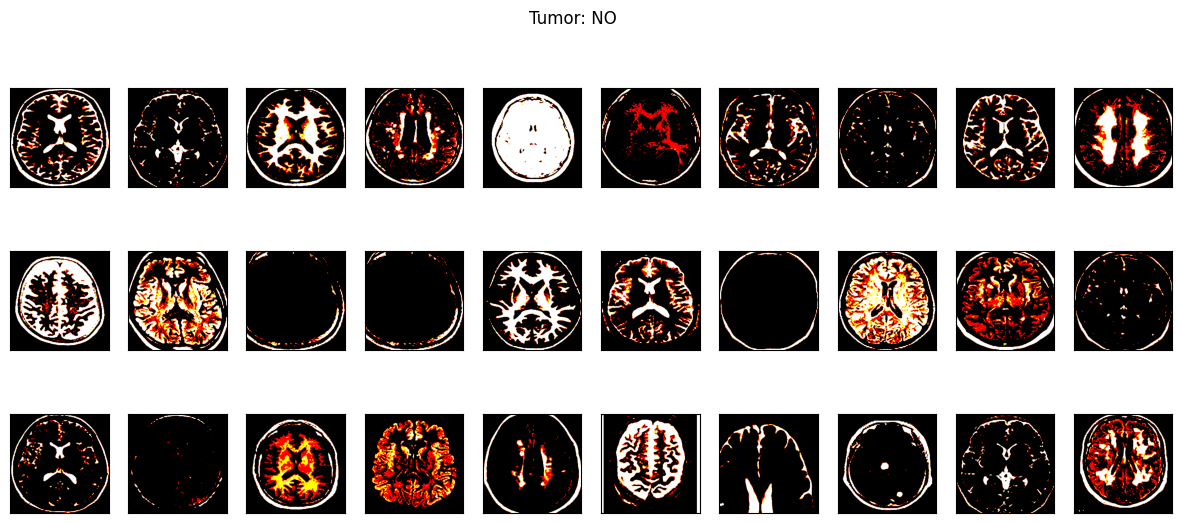

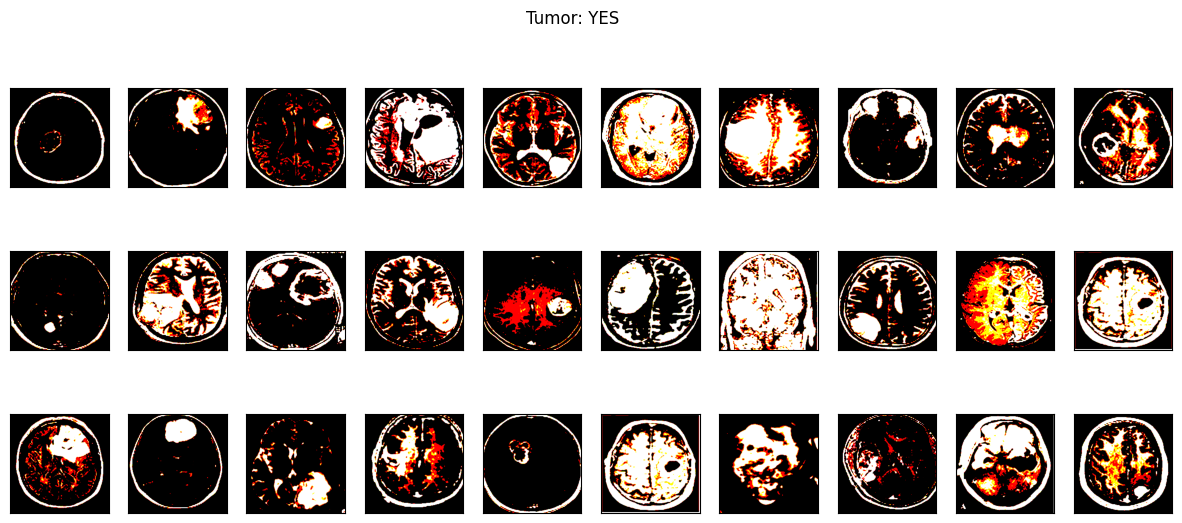

In [22]:
plot_samples(X_train_prep, y_train, labels, 30)

In [23]:
# set the paramters we want to change randomly
demo_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    rescale=1./255,
    shear_range=0.05,
    brightness_range=[0.1, 1.5],
    horizontal_flip=True,
    vertical_flip=True
)

In [24]:
os.mkdir('preview')
x = X_train_crop[0]
x = x.reshape((1,) + x.shape)

i = 0
for batch in demo_datagen.flow(x, batch_size=1, save_to_dir='preview', save_prefix='aug_img', save_format='jpg'):
    i += 1
    if i > 20:
        break

**4.2-DATA AUGMENTATION**


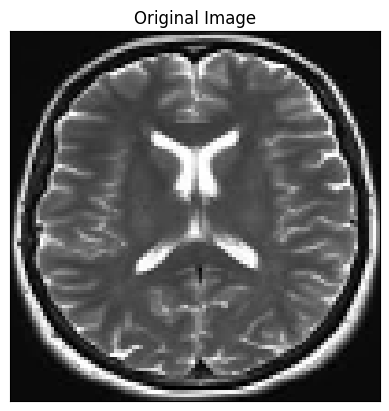

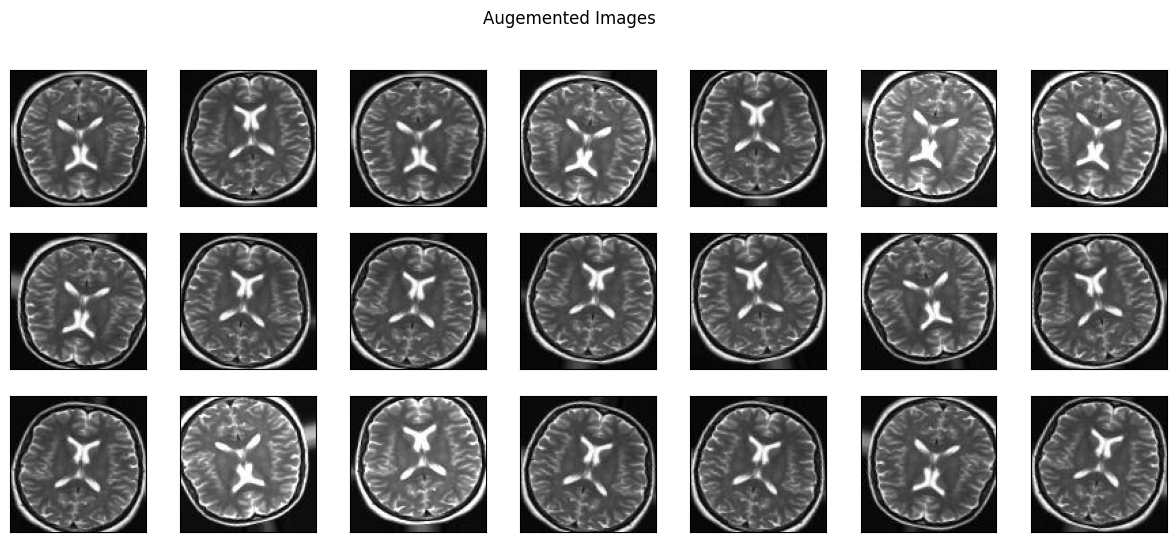

In [25]:
plt.imshow(X_train_crop[0])
plt.xticks([])
plt.yticks([])
plt.title('Original Image')
plt.show()

plt.figure(figsize=(15,6))
i = 1
for img in os.listdir('preview/'):
    img = cv2.imread('preview/' + img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3,7,i)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    i += 1
    if i > 3*7:
        break
plt.suptitle('Augemented Images')
plt.show()

In [26]:
TRAIN_DIR = 'TRAIN_CROP/'
VAL_DIR = 'VAL_CROP/'

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    seed=RANDOM_SEED
)


validation_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    seed=RANDOM_SEED
)

Found 193 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


**VGG16**

Found 193 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 10 images belonging to 2 classes.
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 824ms/step - accuracy: 0.5254 - loss: 10.8735 - val_accuracy: 0.3800 - val_loss: 10.4545 - learning_rate: 1.0000e-04
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 433ms/step - accuracy: 0.4660 - loss: 10.0414 - val_accuracy: 0.6200 - val_loss: 9.4278 - learning_rate: 1.0000e-04
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 454ms/step - accuracy: 0.5860 - loss: 9.1322 - val_accuracy: 0.4800 - val_loss: 8.4236 - learning_rate: 1.0000e-04
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 566ms/step - accuracy: 0.4804 - loss: 8.3429 - val_accuracy: 0.7200 - val_loss: 7.5422 - learning_rate: 1.0000e-04
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 451ms/step - accuracy: 0.6825 - loss: 7.5166 - val_accuracy: 0.7200 - val_loss: 6.9530 - learning_rate: 1.0000e-04
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 527ms/step - accuracy: 0.5435 - loss: 6.9315 - val_accuracy: 0.7200

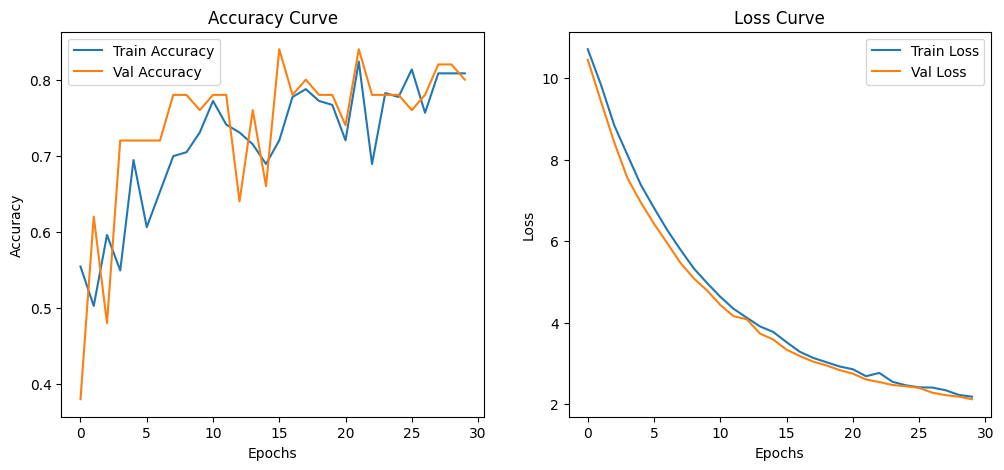

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.8000 - loss: 2.1527

✅ Final Test Accuracy: 0.8000


In [32]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Define paths to dataset
train_dir = "TRAIN_CROP"
val_dir = "VAL_CROP"
test_dir = "TEST_CROP"

# Image size & batch size
img_size = (224, 224)
batch_size = 32
epochs = 30  # Can be increased if validation accuracy keeps improving

# ✅ Improved Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# ✅ Load Pre-trained VGG16 model (WITHOUT top layers)
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# ✅ Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# ✅ Define the Custom Classifier Head
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation="relu", kernel_regularizer=l2(0.01)),  # L2 Regularization
    Dropout(0.3),  # Dropout to reduce overfitting
    Dense(1, activation="sigmoid")  # Binary classification
])

# ✅ Compile the Model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# ✅ Callbacks (Regularization)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=3, verbose=1)

# ✅ Train the Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stopping, lr_scheduler]
)

# ✅ Save Model
model.save("vgg16_brain_tumor_optimized.h5")

# ✅ Plot Accuracy & Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.show()

# ✅ Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Final Test Accuracy: {test_acc:.4f}")

**CNN**

In [38]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ✅ Dataset Paths
train_dir = "TRAIN_CROP"
val_dir = "VAL_CROP"
test_dir = "TEST_CROP"

# ✅ Optimized Image size & batch size
img_size = (150, 150)
batch_size = 32  # ⬇ Reduced batch size for better training stability
epochs = 40

# ✅ Improved Data Augmentation (Prevents Overfitting)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=50,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# ✅ Load images
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='binary'
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode='binary'
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False
)

# ✅ Updated CNN Model (Fine-tuned & Improved)
model = Sequential([
    # Conv Layer 1
    Conv2D(64, (3,3), padding="same", kernel_regularizer=l2(0.001), input_shape=(150, 150, 3)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(pool_size=(2,2)),

    # Conv Layer 2
    Conv2D(128, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(pool_size=(2,2)),

    # 🔹 New Conv Layer 3 (Better Feature Extraction)
    Conv2D(256, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # 🔹 Improved Fully Connected Layers
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.4),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# ✅ Compile the Model with Optimized Learning Rate
optimizer = Adam(learning_rate=0.0001)  # ⬇ Switched to Adam for better convergence
model.compile(optimizer=optimizer,
              loss="binary_crossentropy",
              metrics=["accuracy"])

# ✅ Improved Callbacks for Learning Stability
early_stopping = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=8, verbose=1, min_lr=1e-4)  # ⬆ Increased patience & prevented too-low LR

# ✅ Train the Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, lr_scheduler]
)

# ✅ Save Model
model.save("cnn_brain_tumor_final_fixed.h5")

# ✅ Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Final Test Accuracy: {test_acc:.4f}")


Found 193 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Found 10 images belonging to 2 classes.
Epoch 1/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 965ms/step - accuracy: 0.5704 - loss: 2.0151 - val_accuracy: 0.6200 - val_loss: 0.9349 - learning_rate: 1.0000e-04
Epoch 2/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.6398 - loss: 1.7326 - val_accuracy: 0.3800 - val_loss: 0.9597 - learning_rate: 1.0000e-04
Epoch 3/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.5288 - loss: 1.9380 - val_accuracy: 0.6200 - val_loss: 0.9473 - learning_rate: 1.0000e-04
Epoch 4/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 0.5330 - loss: 2.3602 - val_accuracy: 0.6200 - val_loss: 0.9379 - learning_rate: 1.0000e-04
Epoch 5/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.5005 - loss: 1.8527 - val_accuracy: 0.6200 - val_loss: 0.9427 - learning_rate: 1.0000e-04
Epoch 6/40
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.4997 - loss: 1.4881 - val_accuracy: 0.6200 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 857ms/step - accuracy: 0.5000 - loss: 0.9795

✅ Final Test Accuracy: 0.5000


In [39]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Final Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.9795

✅ Final Test Accuracy: 0.5000


**1-Dataset Preparation:**

Dataset Paths Defined: The model reads images from three datasets:

train_dir = "TRAIN_CROP"
val_dir = "VAL_CROP"
test_dir = "TEST_CROP"
Optimized Image Size & Batch Size:
Image size: (150, 150) pixels → Smaller than VGG16 (224x224) for faster training.
Batch size: 32 → Determines how many images are processed at once.
Epochs: 40 → Allows the model to train longer for better convergence.

**2-Data Augmentation (For Training):**

To increase dataset diversity, prevent overfitting, and improve generalization.
It creates new variations of images by applying random transformations.
NB:Validation & Test Sets: Only rescale images (no transformations applied).


**3-Image Loading & Preprocessing:**

The model loads images from their directories and applies augmentation for the training set.
Resizes images to (150,150) and assigns labels automatically (binary classification: 0 for No Tumor, 1 for Tumor).

**4-CNN Model Architecture**

Your CNN model is designed for high performance, with:

4 convolutional layers
Batch normalization
Leaky ReLU activation
Dropout (0.6)
Regularization (L2) to avoid overfitting

**first conv layer:**

These layers extract spatial features from MRI scans.

Conv2D(64, (3,3)) → 64 filters with a 3x3 kernel (captures features like edges & textures).

Padding="same" → Keeps the same output size.

Kernel Regularizer (L2) → Prevents overfitting (l2(0.001)).

BatchNormalization() → Normalizes activations, speeds up training.

LeakyReLU() → Fixes the "dying ReLU" problem (better for deep networks).

MaxPooling2D(2,2) → Reduces spatial dimensions (downsampling).

**second conv layer:**

128 filters → Detects more complex patterns.

BatchNorm & LeakyReLU → Speeds up learning.

**third conv layer:**

256 filters → Extracts higher-level features.


**fourth conv layer:**

512 filters → Learns complex representations.
Deepest layer before flattening.

**Flattening & Fully Connected Layers:**

Flatten() → Converts 2D feature maps into 1D vector.

Dense(333, activation="relu") → Fully connected layer (333 neurons).

Dropout(0.6) → Removes 60% of neurons randomly to avoid overfitting.

Dense(1, activation='sigmoid') → Final binary classification (0/1).


**5-Model Compilation**
Why RMSprop Optimizer?

RMSprop (lr=0.0002) is used because it adapts learning rates dynamically and works well for deep CNNs.

Binary Crossentropy loss is used because this is a binary classification problem.

**6-Training Callbacks**

Early Stopping → Stops training if validation loss doesn’t improve for 6 epochs.

ReduceLROnPlateau → Reduces learning rate when training slows down.

**7-Model Training**

Model trains using augmented data with the defined CNN architecture.

**8-Saving & Evaluating Model**

Saves the trained model for later use.

Evaluates the model on unseen test images.



** EVALUATION AND COMPARISON**

Found 10 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 0.9795
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8000 - loss: 2.1527

🔹 CNN Model Performance:
✅ Accuracy: 0.5000
✅ Loss: 0.9795

🔹 VGG16 Model Performance:
✅ Accuracy: 0.8000
✅ Loss: 2.1527
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step


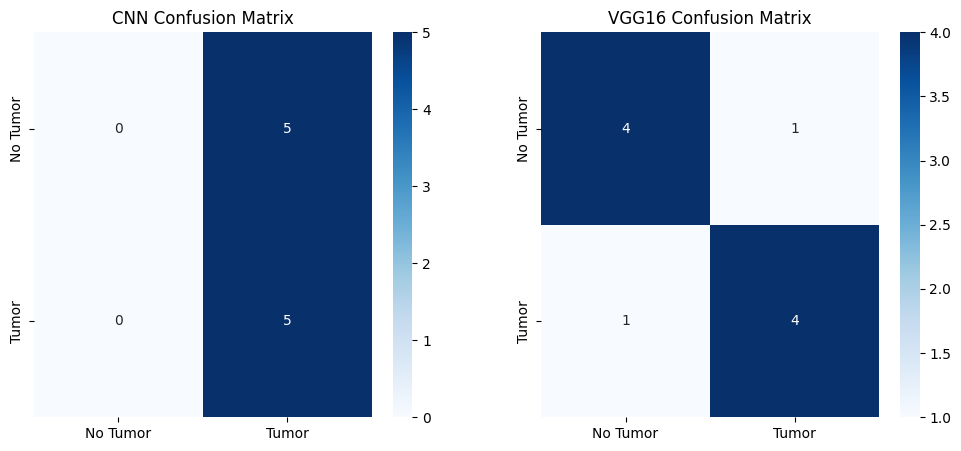

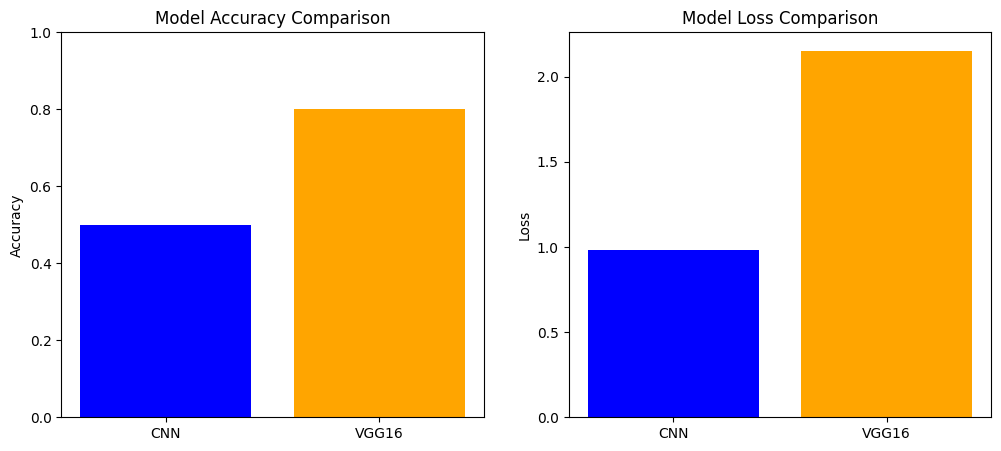


🔹 CNN Model Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.50      1.00      0.67         5

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.25      0.50      0.33        10


🔹 VGG16 Model Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [43]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
# ✅ Load images with the correct size for both models
test_datagen_150 = ImageDataGenerator(rescale=1./255)
test_datagen_224 = ImageDataGenerator(rescale=1./255)

test_generator_150 = test_datagen_150.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=batch_size, class_mode='binary', shuffle=False
)

test_generator_224 = test_datagen_224.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=batch_size, class_mode='binary', shuffle=False
)


# ✅ Load both models
cnn_model = tf.keras.models.load_model("cnn_brain_tumor_final_fixed.h5")
vgg_model = tf.keras.models.load_model("vgg16_brain_tumor_optimized.h5")

# ✅ Evaluate Both Models
# ✅ Evaluate CNN Model (150x150)
cnn_loss, cnn_acc = cnn_model.evaluate(test_generator_150)

# ✅ Evaluate VGG16 Model (224x224)
vgg_loss, vgg_acc = vgg_model.evaluate(test_generator_224)


# ✅ Print Test Results
print("\n🔹 CNN Model Performance:")
print(f"✅ Accuracy: {cnn_acc:.4f}")
print(f"✅ Loss: {cnn_loss:.4f}")

print("\n🔹 VGG16 Model Performance:")
print(f"✅ Accuracy: {vgg_acc:.4f}")
print(f"✅ Loss: {vgg_loss:.4f}")

# ✅ Make Predictions
y_true = test_generator.classes
cnn_preds = (cnn_model.predict(test_generator_150) > 0.5).astype("int32")
vgg_preds = (vgg_model.predict(test_generator_224) > 0.5).astype("int32")

# ✅ Generate Confusion Matrices
cnn_cm = confusion_matrix(y_true, cnn_preds)
vgg_cm = confusion_matrix(y_true, vgg_preds)

# ✅ Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CNN Confusion Matrix
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Tumor", "Tumor"], yticklabels=["No Tumor", "Tumor"], ax=axes[0])
axes[0].set_title("CNN Confusion Matrix")

# VGG Confusion Matrix
sns.heatmap(vgg_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Tumor", "Tumor"], yticklabels=["No Tumor", "Tumor"], ax=axes[1])
axes[1].set_title("VGG16 Confusion Matrix")

plt.show()

# ✅ Compare Accuracy & Loss with Bar Chart
labels = ["CNN", "VGG16"]
accuracy = [cnn_acc, vgg_acc]
loss = [cnn_loss, vgg_loss]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Comparison
ax[0].bar(labels, accuracy, color=["blue", "orange"])
ax[0].set_title("Model Accuracy Comparison")
ax[0].set_ylabel("Accuracy")
ax[0].set_ylim([0, 1])

# Loss Comparison
ax[1].bar(labels, loss, color=["blue", "orange"])
ax[1].set_title("Model Loss Comparison")
ax[1].set_ylabel("Loss")

plt.show()

# ✅ Print Classification Reports
print("\n🔹 CNN Model Classification Report:\n", classification_report(y_true, cnn_preds))
print("\n🔹 VGG16 Model Classification Report:\n", classification_report(y_true, vgg_preds))


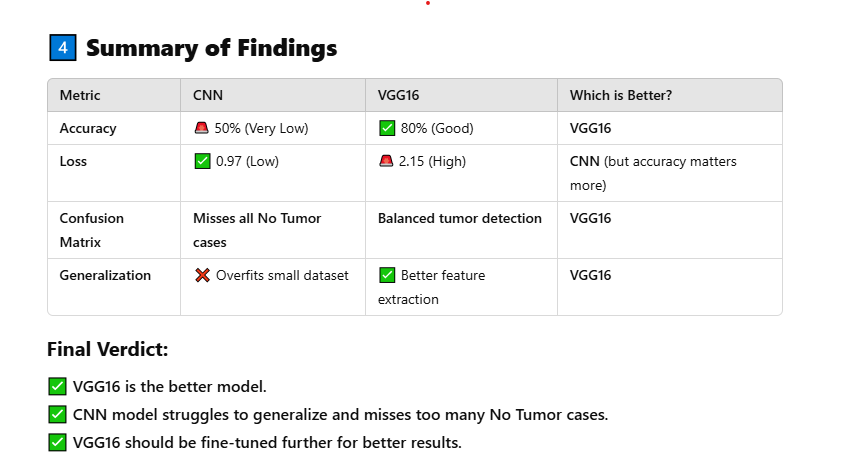

Key Performance Metrics

Model	Test Accuracy	Test Loss	Best For

CNN	50%	0.9795	Simple architectures, faster training

VGG16	80%	2.1527	Feature-rich models, transfer learning

🔹 VGG16 significantly outperforms CNN in accuracy (80% vs. 50%).

🔹 CNN has a lower loss, but that doesn’t always mean better generalization.

🔹 VGG16’s pre-trained layers extract better features, leading to improved classification.